In [ ]:
!pip install pyspark

# 🔥 Phase 1 — Data Pipeline (PySpark)

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import pandas as pd

spark = SparkSession.builder \
    .appName("FraudDetection") \
    .getOrCreate()

In [ ]:
spark

loading the transaction file

In [ ]:
tx_df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("nullValue", "NA") \
    .csv("train_transaction.csv")

AnalysisException: [PATH_NOT_FOUND] Path does not exist: file:/content/train_transaction.csv. SQLSTATE: 42K03

In [ ]:
print(tx_df.count(), len(tx_df.columns))

590540 394


loading the identity file

In [ ]:
id_df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("nullValue", "NA") \
    .csv("train_identity.csv")

In [ ]:
print(id_df.count(), len(id_df.columns))

144233 41


In [ ]:
tx_df.select("TransactionID").distinct().count()

590540

joining both tables

In [ ]:
df = tx_df.join(id_df, on="TransactionID", how="left")

print(df.count(), len(df.columns))

590540 434


Window functions

In [ ]:
window_7d = Window.partitionBy("card1") \
                  .orderBy("TransactionDT") \
                  .rangeBetween(-7 * 24 * 3600, 0)

- partitionBy("card1") — group by card. Every card gets its own independent
window, same card1 value = same group.

- orderBy("TransactionDT") — within each card's group, order transactions by time. TransactionDT is time measured in seconds.

- rangeBetween(-7 * 24 * 3600, 0) — for each transaction, look back exactly 7 days worth of seconds and up to the current transaction. Nothing in the future, nothing older than 7 days

In [ ]:
df = df.withColumn("tx_count_7d", F.count("TransactionID").over(window_7d))

F.count("TransactionID").over(window_7d) :

for each transaction, count how many TransactionIDs exist within that card's 7 day window we defined

In [ ]:
window_unbounded = Window.partitionBy("card1") \
                         .orderBy("TransactionDT") \
                         .rowsBetween(Window.unboundedPreceding, Window.currentRow)

df = df.withColumn("amt_running_mean", F.mean("TransactionAmt").over(window_unbounded)) \
       .withColumn("amt_running_std", F.stddev("TransactionAmt").over(window_unbounded))

looks at everything from the very first transaction of that card up to the current one. That's what unboundedPreceding means — no limit going back.
We use this to compute:

- amt_running_mean — the average amount this card has ever spent up to this point in time

- amt_running_std — how much that amount varies. A card that always spends between $10-$20 has low std. A card all over the place has high std.

calculate z score

In [ ]:
df = df.withColumn("amt_zscore",
    F.when(
        F.col("amt_running_std") > 0,
        (F.col("TransactionAmt") - F.col("amt_running_mean")) / F.col("amt_running_std")
    ).otherwise(F.lit(0.0))
)

In [ ]:
df.select("TransactionID", "card1", "TransactionAmt",
          "tx_count_7d", "amt_running_mean",
          "amt_running_std", "amt_zscore").show(10)

+-------------+-----+--------------+-----------+------------------+------------------+-------------------+
|TransactionID|card1|TransactionAmt|tx_count_7d|  amt_running_mean|   amt_running_std|         amt_zscore|
+-------------+-----+--------------+-----------+------------------+------------------+-------------------+
|      3038871| 1005|          50.0|          1|              50.0|              NULL|                0.0|
|      3232272| 1008|         57.95|          1|             57.95|              NULL|                0.0|
|      3280242| 1008|         100.0|          1|            78.975|29.733840148894323| 0.7071067811865477|
|      3537798| 1008|          24.5|          1| 60.81666666666666|37.831545479048735| -0.959957258071283|
|      3378279| 1010|       277.932|          1|           277.932|              NULL|                0.0|
|      3173890| 1016|         335.0|          1|             335.0|              NULL|                0.0|
|      3235807| 1016|        210.95| 

saving the file

Why Parquet and not just CSV:

- Compressed — Parquet will be significantly smaller than the equivalent CSV despite having more columns now

- Columnar — CSV stores data row by row. Parquet stores it column by column. When your model in Phase 2 needs only 20 columns out of 434, Parquet reads only those 20. CSV has to read every row entirely just to get those columns. Much faster.

- Type safe — CSV stores everything as text, types get lost. Parquet remembers that TransactionAmt is a double and isFraud is an integer. No re-inferring needed next time.



saving the parquet folder in the drive





In [ ]:
df.write.mode("overwrite").parquet("/content/drive/MyDrive/fraud_detection/fraud_data_phase1.parquet")

# 🔧 Phase 2 — Feature Engineering

In [ ]:
import pandas as pd

missing = df.select([F.mean(F.col(c).isNull().cast("int")).alias(c) for c in df.columns])
missing_pd = missing.toPandas().T
missing_pd.columns = ["missing_rate"]
missing_pd = missing_pd.sort_values("missing_rate", ascending=False)
print(missing_pd[missing_pd["missing_rate"] > 0.5])

       missing_rate
id_24      0.991962
id_25      0.991310
id_08      0.991271
id_07      0.991271
id_21      0.991264
...             ...
M5         0.593494
M7         0.586353
M8         0.586331
M9         0.586331
D5         0.524674

[214 rows x 1 columns]


In [ ]:
print("Above 80% missing:", len(missing_pd[missing_pd["missing_rate"] > 0.8]))
print("Between 50-80% missing:", len(missing_pd[(missing_pd["missing_rate"] > 0.5) & (missing_pd["missing_rate"] <= 0.8)]))

Above 80% missing: 74
Between 50-80% missing: 140


In [ ]:
cols_to_drop = missing_pd[missing_pd["missing_rate"] > 0.8].index.tolist()
df = df.drop(*cols_to_drop)
print(len(df.columns))

364


numerical and Categorical columns

In [ ]:
cat_cols = [c for c, t in df.dtypes if t == "string"]
num_cols = [c for c, t in df.dtypes if t != "string"]

print("Categorical columns:", len(cat_cols))
print("Numerical columns:", len(num_cols))
print("\nCategorical column names:", cat_cols)

Categorical columns: 26
Numerical columns: 338

Categorical column names: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_31', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


In [ ]:
for col in cat_cols:
    n_unique = df.select(col).distinct().count()
    print(f"{col}: {n_unique} unique values")

ProductCD: 5 unique values
card4: 5 unique values
card6: 5 unique values
P_emaildomain: 60 unique values
R_emaildomain: 61 unique values
M1: 3 unique values
M2: 3 unique values
M3: 3 unique values
M4: 4 unique values
M5: 3 unique values
M6: 3 unique values
M7: 3 unique values
M8: 3 unique values
M9: 3 unique values
id_12: 3 unique values
id_15: 4 unique values
id_16: 3 unique values
id_28: 3 unique values
id_29: 3 unique values
id_31: 131 unique values
id_35: 3 unique values
id_36: 3 unique values
id_37: 3 unique values
id_38: 3 unique values
DeviceType: 3 unique values
DeviceInfo: 1787 unique values


Splitting the data

---



we  **use time-based split** , to split the data based on time (training data =
old transactions, test data = new ones), to prevent giving the model future informations



In [ ]:
df.select(F.min("TransactionDT"), F.max("TransactionDT")).show()

+------------------+------------------+
|min(TransactionDT)|max(TransactionDT)|
+------------------+------------------+
|             86400|          15811131|
+------------------+------------------+



This dataset covers roughly 6 months of transactions. Now we'll split it:

- Train — first 80% of that time range → day 1 to day 146

- Test — last 20% → day 146 to day 183


The split point in seconds is:

86400 + (15811131 - 86400) × 0.8 = roughly 12,674,265 seconds

In [ ]:
split_point = 86400 + (15811131 - 86400) * 0.8

train_df = df.filter(F.col("TransactionDT") <= split_point)
test_df = df.filter(F.col("TransactionDT") > split_point)

print("Train size:", train_df.count())
print("Test size:", test_df.count())

Train size: 485903
Test size: 104637


to prevent leakage :

1. Look at only the train set
2. For each unique email domain, calculate what percentage of its transactions are fraud
3. Store that as a dictionary — {"gmail.com": 0.02, "yahoo.com": 0.04, ...}
4. Replace the email domain text with that number in both train and test

In [ ]:
high_cardinality = ["P_emaildomain", "R_emaildomain", "id_31", "DeviceInfo"]

overall_fraud_rate = train_df.agg(F.mean("isFraud")).collect()[0][0]
print(f"Overall fraud rate: {overall_fraud_rate:.4f}")

Overall fraud rate: 0.0352


using taret encoding for high cardinality

In [ ]:
for col in high_cardinality:
    # Compute fraud rate per category from train only
    rate_map = train_df.groupBy(col).agg(
        F.mean("isFraud").alias("fraud_rate")
    )

    # Apply to train
    train_df = train_df.join(rate_map, on=col, how="left") \
                       .withColumn(col, F.coalesce(F.col("fraud_rate"), F.lit(overall_fraud_rate))) \
                       .drop("fraud_rate")

    # Apply to test
    test_df = test_df.join(rate_map, on=col, how="left") \
                     .withColumn(col, F.coalesce(F.col("fraud_rate"), F.lit(overall_fraud_rate))) \
                     .drop("fraud_rate")

print("Done")

Done


using hot encoding

In [ ]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline

low_cardinality = [c for c in cat_cols if c not in high_cardinality]
print("Columns to one hot encode:", low_cardinality)

Columns to one hot encode: ['ProductCD', 'card4', 'card6', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType']


- Step 1 — StringIndexer:
Spark can't one hot encode text directly. It first needs to convert text to numbers. So "desktop"=0, "mobile"=1, "notfound"=2. This is just an intermediate step, not the final encoding.
- Step 2 — OneHotEncoder:
Takes those numbers from step 1 and converts them into binary columns. So 0 becomes [1,0,0], 1 becomes [0,1,0] etc.

In [ ]:
# Step 1 - StringIndexer for each column
indexers = [
    StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep")
    for c in low_cardinality
]

# Step 2 - OneHotEncoder for each indexed column
encoders = [
    OneHotEncoder(inputCol=c+"_idx", outputCol=c+"_ohe")
    for c in low_cardinality
]

# Chain everything into a pipeline
pipeline = Pipeline(stages=indexers + encoders)

# Fit on train only
pipeline_model = pipeline.fit(train_df)

# Apply to both
train_df = pipeline_model.transform(train_df)
test_df = pipeline_model.transform(test_df)

print("Done")

Done


- StringIndexer converted text to numbers → created _idx columns like DeviceType_idx
- OneHotEncoder converted those numbers to binary columns → created _ohe columns like DeviceType_ohe

In [ ]:
# Drop original text columns and intermediate index columns
cols_to_remove = low_cardinality + [c+"_idx" for c in low_cardinality]
train_df = train_df.drop(*cols_to_remove)
test_df = test_df.drop(*cols_to_remove)

print("Train columns:", len(train_df.columns))
print("Test columns:", len(test_df.columns))

Train columns: 364
Test columns: 364


The issue is the _ohe columns in Spark are stored as vectors not individual columns — meaning all the binary values for DeviceType are packed into one column called DeviceType_ohe as a single vector object, not expanded into separate columns yet.

In [ ]:
train_df.select("DeviceType_ohe").show(5, truncate=False)

+--------------+
|DeviceType_ohe|
+--------------+
|(2,[],[])     |
|(2,[],[])     |
|(2,[],[])     |
|(2,[1],[1.0]) |
|(2,[0],[1.0]) |
+--------------+
only showing top 5 rows


In [ ]:
from pyspark.ml.functions import vector_to_array

ohe_cols = [c+"_ohe" for c in low_cardinality]

for c in ohe_cols:
    # Convert vector to array then expand into individual columns
    train_df = train_df.withColumn(c, vector_to_array(F.col(c)))
    test_df = test_df.withColumn(c, vector_to_array(F.col(c)))

    # Get the size of the vector
    size = len(train_df.select(c).first()[0])

    # Create individual columns
    for i in range(size):
        train_df = train_df.withColumn(f"{c}_{i}", F.col(c)[i])
        test_df = test_df.withColumn(f"{c}_{i}", F.col(c)[i])

    # Drop the vector column
    train_df = train_df.drop(c)
    test_df = test_df.drop(c)

print("Train columns:", len(train_df.columns))
print("Test columns:", len(test_df.columns))

Train columns: 395
Test columns: 395


PCA

In [ ]:
v_cols = [c for c in train_df.columns if c.startswith("V")]
print("Number of V columns:", len(v_cols))

Number of V columns: 292


In [ ]:
from pyspark.ml.feature import VectorAssembler, PCA
from pyspark.ml.functions import vector_to_array

# Fill nulls in V columns with 0 before PCA
train_df = train_df.fillna(0, subset=v_cols)
test_df = test_df.fillna(0, subset=v_cols)

# Assemble all V columns into one vector column (PCA requires this)
assembler = VectorAssembler(inputCols=v_cols, outputCol="v_features")
train_assembled = assembler.transform(train_df)
test_assembled = assembler.transform(test_df)

# Run PCA with 30 components
pca = PCA(k=30, inputCol="v_features", outputCol="v_pca")
pca_model = pca.fit(train_assembled)

# How much variance is explained?
explained = pca_model.explainedVariance.toArray()
cumulative = explained.cumsum()
print(f"Variance explained by 30 components: {cumulative[-1]*100:.2f}%")

Variance explained by 30 components: 99.90%


apply pca to both train and test
transfor back vectors to columns
drop original v columns

In [ ]:
# Transform both train and test
train_pca = pca_model.transform(train_assembled)
test_pca = pca_model.transform(test_assembled)

# Expand PCA vector into individual columns
train_pca = train_pca.withColumn("v_pca", vector_to_array(F.col("v_pca")))
test_pca = test_pca.withColumn("v_pca", vector_to_array(F.col("v_pca")))

for i in range(30):
    train_pca = train_pca.withColumn(f"pca_{i}", F.col("v_pca")[i])
    test_pca = test_pca.withColumn(f"pca_{i}", F.col("v_pca")[i])

# Drop original V columns, assembled vector, and PCA vector
cols_to_remove = v_cols + ["v_features", "v_pca"]
train_pca = train_pca.drop(*cols_to_remove)
test_pca = test_pca.drop(*cols_to_remove)

print("Train columns:", len(train_pca.columns))
print("Test columns:", len(test_pca.columns))

Train columns: 133
Test columns: 133


we should switch from Spark dataframes to Pandas at this point. The heavy Spark processing is done, our data is now clean and encoded.

Model training with XGBoost and LightGBM in Python works on Pandas dataframes or numpy arrays — they don't speak Spark natively

In [ ]:
train_pca.write.mode("overwrite").parquet("/content/drive/MyDrive/fraud_detection/train_phase2.parquet")
test_pca.write.mode("overwrite").parquet("/content/drive/MyDrive/fraud_detection/test_phase2.parquet")

print("Saved to Drive")

Saved to Drive


In [ ]:
train_pd = pd.read_parquet("/content/drive/MyDrive/fraud_detection/train_phase2.parquet")
test_pd = pd.read_parquet("/content/drive/MyDrive/fraud_detection/test_phase2.parquet")

print("Train shape:", train_pd.shape)
print("Test shape:", test_pd.shape)

Train shape: (485903, 133)
Test shape: (104637, 133)


In [ ]:
spark.stop()

In [ ]:
null_counts = train_pd.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)

print(f"Columns with nulls: {len(null_counts)}")
print(null_counts.head(20))

Columns with nulls: 24
id_13              378653
id_05              369290
id_06              369290
id_20              367109
id_19              367083
id_17              367043
id_02              366025
id_11              365912
id_01              363187
dist1              294284
D5                 260402
D11                249644
D2                 236943
D3                 222892
D4                 143193
D15                 79198
D10                 67459
addr1               54949
addr2               54949
amt_running_std     12824
dtype: int64


handle missing data

- For most numerical columns — median imputation. Our data has outliers and skewed distributions so median is safer than mean.
- For columns where missingness is meaningful — like the D columns (time deltas) where a null might mean "first transaction ever" — we'll fill with -1 to preserve that signal.

In [ ]:
# Columns to fill with -1 (meaningful absence)
fill_minus1 = [c for c in train_pd.columns if c.startswith("id_")] + \
              [c for c in train_pd.columns if c.startswith("D")]

# Columns to fill with median (continuous measurements)
fill_median = ["dist1", "addr1", "addr2", "card2", "card3", "card5"]

# Columns to fill with 0 (we created these, null means no history)
fill_zero = ["amt_running_std"]

# Compute medians from train only — no leakage
medians = train_pd[fill_median].median()

# Apply to train
train_pd[fill_minus1] = train_pd[fill_minus1].fillna(-1)
train_pd[fill_median] = train_pd[fill_median].fillna(medians)
train_pd[fill_zero] = train_pd[fill_zero].fillna(0)

# Apply to test using train medians
test_pd[fill_minus1] = test_pd[fill_minus1].fillna(-1)
test_pd[fill_median] = test_pd[fill_median].fillna(medians)
test_pd[fill_zero] = test_pd[fill_zero].fillna(0)

# Verify
print("Train nulls remaining:", train_pd.isnull().sum().sum())
print("Test nulls remaining:", test_pd.isnull().sum().sum())

Train nulls remaining: 0
Test nulls remaining: 0


**feature creation**
we are adding new colums to our data
1. has_identity
A simple 0 or 1 — did this transaction have identity info or not. We discussed earlier that missing identity is meaningful. Instead of leaving it scattered across 40 null id columns, we capture it in one clean signal.
2. amount_to_mean_ratio
How does this transaction's amount compare to that card's running average? We already have TransactionAmt and amt_running_mean from Phase 1. Dividing them gives us a ratio — 1.0 means perfectly normal, 3.0 means three times the usual amount, very suspicious.
3. is_high_velocity
A binary flag — 1 if this card made more than 5 transactions in the last 7 days, 0 otherwise. We already have tx_count_7d from Phase 1. We just convert it into a clean binary signal.

In [ ]:
# 1. has_identity — was identity info captured for this transaction?
identity_cols = [c for c in train_pd.columns if c.startswith("id_")]
train_pd["has_identity"] = (train_pd[identity_cols] != -1).any(axis=1).astype(int)
test_pd["has_identity"] = (test_pd[identity_cols] != -1).any(axis=1).astype(int)

# 2. amount_to_mean_ratio — how unusual is this amount for this card?
train_pd["amount_to_mean_ratio"] = train_pd["TransactionAmt"] / (train_pd["amt_running_mean"] + 1)
test_pd["amount_to_mean_ratio"] = test_pd["TransactionAmt"] / (test_pd["amt_running_mean"] + 1)

# 3. is_high_velocity — is this card transacting unusually frequently?
train_pd["is_high_velocity"] = (train_pd["tx_count_7d"] > 5).astype(int)
test_pd["is_high_velocity"] = (test_pd["tx_count_7d"] > 5).astype(int)

print("New shape:", train_pd.shape)
print("\nSample of new features:")
train_pd[["TransactionAmt", "amt_running_mean", "amount_to_mean_ratio",
          "tx_count_7d", "is_high_velocity", "has_identity"]].head(10)

New shape: (485903, 136)

Sample of new features:


,TransactionAmt,amt_running_mean,amount_to_mean_ratio,tx_count_7d,is_high_velocity,has_identity
0,183.000,183.000000,0.994565,1,0,1
1,29.000,106.000000,0.271028,1,0,1
2,27.000,79.666667,0.334711,1,0,1
3,150.000,150.000000,0.993377,1,0,1
4,150.000,150.000000,0.993377,1,0,1
5,100.000,133.333333,0.744417,1,0,1
6,23.203,23.203000,0.958683,1,0,1
7,55.164,39.183500,1.372802,1,0,1
8,200.000,200.000000,0.995025,1,0,1
9,200.000,200.000000,0.995025,2,0,1


saving to drive

In [ ]:
train_pd.to_parquet("/content/drive/MyDrive/fraud_detection/train_final.parquet", index=False)
test_pd.to_parquet("/content/drive/MyDrive/fraud_detection/test_final.parquet", index=False)

print("Train shape saved:", train_pd.shape)
print("Test shape saved:", test_pd.shape)
print("Phase 2 complete ")

Train shape saved: (485903, 136)
Test shape saved: (104637, 136)
Phase 2 complete 


# 🤖 Phase 3 — Modeling

In [ ]:
import pandas as pd
import numpy as np

train_pd = pd.read_parquet("/content/drive/MyDrive/fraud_detection/train_final.parquet")
test_pd = pd.read_parquet("/content/drive/MyDrive/fraud_detection/test_final.parquet")

print("Train shape:", train_pd.shape)
print("Test shape:", test_pd.shape)

Train shape: (485903, 136)
Test shape: (104637, 136)


- X — the features, everything the model uses to make a prediction

- y — the target, what we're trying to predict (isFraud)

So X is the input, y is the answer. The model learns the relationship between X and y during training, then uses only X to predict y on new unseen transactions

In [ ]:
TARGET = "isFraud"

X_train = train_pd.drop(columns=[TARGET])
y_train = train_pd[TARGET]

X_test = test_pd.drop(columns=[TARGET])
y_test = test_pd[TARGET]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("\nFraud rate in train:", round(y_train.mean() * 100, 2), "%")
print("Fraud rate in test:", round(y_test.mean() * 100, 2), "%")

X_train: (485903, 135)
X_test: (104637, 135)

Fraud rate in train: 3.52 %
Fraud rate in test: 3.4 %


In [ ]:
!pip install xgboost lightgbm optuna -q

**scale_pos_weight** tells XGBoost how much more to penalize missing a fraud case vs missing a legitimate case

The formula is simple:

number of legitimate transactions / number of fraud transactions

(485,903 - 17,100) / 17,100  = 27.41

legitimate transactions outnumber fraud transactions by about 27 to 1.

**scale_pos_weight=27.41**

XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Calculate scale_pos_weight
scale = (len(y_train) - y_train.sum()) / y_train.sum()

# Define model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate
print("AUC-ROC:", round(roc_auc_score(y_test, y_prob), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

AUC-ROC: 0.8733

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.93    101075
           1       0.18      0.73      0.29      3562

    accuracy                           0.88    104637
   macro avg       0.59      0.81      0.61    104637
weighted avg       0.96      0.88      0.91    104637



LightGBM

In [ ]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

print("AUC-ROC:", round(roc_auc_score(y_test, y_prob_lgbm), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 17101, number of negative: 468802
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.235156 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17557
[LightGBM] [Info] Number of data points in the train set: 485903, number of used features: 133
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035194 -> initscore=-3.311044
[LightGBM] [Info] Start training from score -3.311044
AUC-ROC: 0.8819

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.87      0.93    101075
           1       0.17      0.75      0.28      3562

    accuracy                           0.87    104637
   macro avg       0.58      0.81      0.61    104637
weighted avg       0.96      0.87      0.91    104637



update hyperparametres with optuna

In [ ]:
joblib.dump(lgbm_model, "/content/drive/MyDrive/fraud_detection/lgbm_baseline.pkl")
joblib.dump(xgb_model, "/content/drive/MyDrive/fraud_detection/xgb_baseline.pkl")

print("Models saved")

NameError: name 'lgbm_model' is not defined

loading back

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

train_pd = pd.read_parquet("/content/drive/MyDrive/fraud_detection/train_final.parquet")
test_pd = pd.read_parquet("/content/drive/MyDrive/fraud_detection/test_final.parquet")

TARGET = "isFraud"
X_train = train_pd.drop(columns=[TARGET])
y_train = train_pd[TARGET]
X_test = test_pd.drop(columns=[TARGET])
y_test = test_pd[TARGET]

scale = (len(y_train) - y_train.sum()) / y_train.sum()
print("scale_pos_weight:", round(scale, 2))

In [ ]:
lgbm_model = joblib.load("/content/drive/MyDrive/fraud_detection/lgbm_baseline.pkl")
xgb_model = joblib.load("/content/drive/MyDrive/fraud_detection/xgb_baseline.pkl")

print("Models loaded")

Models loaded


In [ ]:
import optuna
from sklearn.model_selection import cross_val_score
from lightgbm import LGBMClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "num_leaves": trial.suggest_int("num_leaves", 20, 200),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "scale_pos_weight": scale,
        "random_state": 42,
        "n_jobs": -1
    }

    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_train, y_train,
                             cv=5, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best AUC-ROC:", round(study.best_value, 4))
print("Best parameters:", study.best_params)

[W 2026-05-19 19:09:26,218] Trial 30 failed with parameters: {'n_estimators': 280, 'max_depth': 9, 'learning_rate': 0.03018190725091831, 'num_leaves': 112, 'min_child_samples': 46} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_13018/2467439162.py", line 20, in objective
    scores = cross_val_score(model, X_train, y_train,
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 684, in cross_val_score
    cv_results = cross_validate(
                 ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12

KeyboardInterrupt: 

In [ ]:
best_params = {
    "n_estimators": 196,
    "max_depth": 8,
    "learning_rate": 0.016550473521207053,
    "num_leaves": 53,
    "min_child_samples": 78,
    "scale_pos_weight": scale,
    "random_state": 42,
    "n_jobs": -1
}

tuned_lgbm = LGBMClassifier(**best_params)
tuned_lgbm.fit(X_train, y_train)

y_pred_tuned = tuned_lgbm.predict(X_test)
y_prob_tuned = tuned_lgbm.predict_proba(X_test)[:, 1]

print("AUC-ROC:", round(roc_auc_score(y_test, y_prob_tuned), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

[LightGBM] [Info] Number of positive: 17101, number of negative: 468802
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.226468 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17553
[LightGBM] [Info] Number of data points in the train set: 485903, number of used features: 131
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035194 -> initscore=-3.311044
[LightGBM] [Info] Start training from score -3.311044
AUC-ROC: 0.8897

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.87      0.93    101075
           1       0.17      0.74      0.28      3562

    accuracy                           0.87    104637
   macro avg       0.58      0.81      0.60    104637
weighted avg       0.96      0.87      0.91    104637



save the tuned lightbg model

In [ ]:
# Model saved as lgbm_final.pkl at end of phase 3

Tuned model saved


 plotting a Precision-Recall curve (Threshold score)

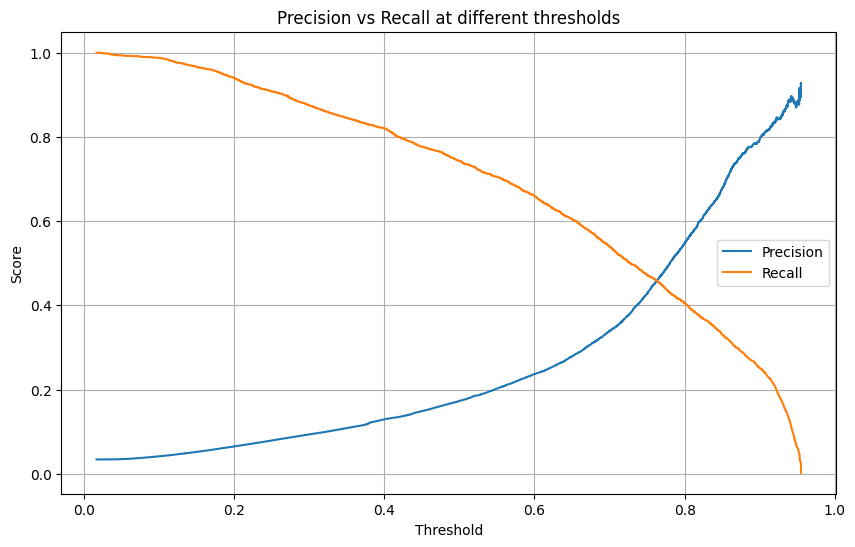

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_tuned)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall at different thresholds")
plt.legend()
plt.grid(True)
plt.show()

For a bank fraud system, recall is priority. So a reasonable choice is threshold around 0.3-0.4 where:

- Recall is still ~0.80-0.85 — catching most fraud
- Precision is ~0.10-0.13 — acceptable false alarm rate

In [ ]:
threshold = 0.35

y_pred_threshold = (y_prob_tuned >= threshold).astype(int)

print(f"Results at threshold {threshold}:")
print(classification_report(y_test, y_pred_threshold))

Results at threshold 0.35:
              precision    recall  f1-score   support

           0       0.99      0.76      0.86    101075
           1       0.11      0.85      0.19      3562

    accuracy                           0.76    104637
   macro avg       0.55      0.80      0.53    104637
weighted avg       0.96      0.76      0.84    104637



**SHAP**

SHAP assigns each feature a score for each individual prediction. That score answers: "how much did this feature push the prediction toward fraud or away from fraud for this specific transaction?"

For example for transaction 1234:

- amt_zscore = +0.8 → this pushed the prediction toward fraud by 0.8
- tx_count_7d = +0.5 → high velocity also pushed toward fraud
- has_identity = -0.3 → having identity info pushed slightly away from fraud

Every prediction becomes explainable. You can tell exactly why the model flagged it.

GLOBAL SHAP (which features matter most across all predictions)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


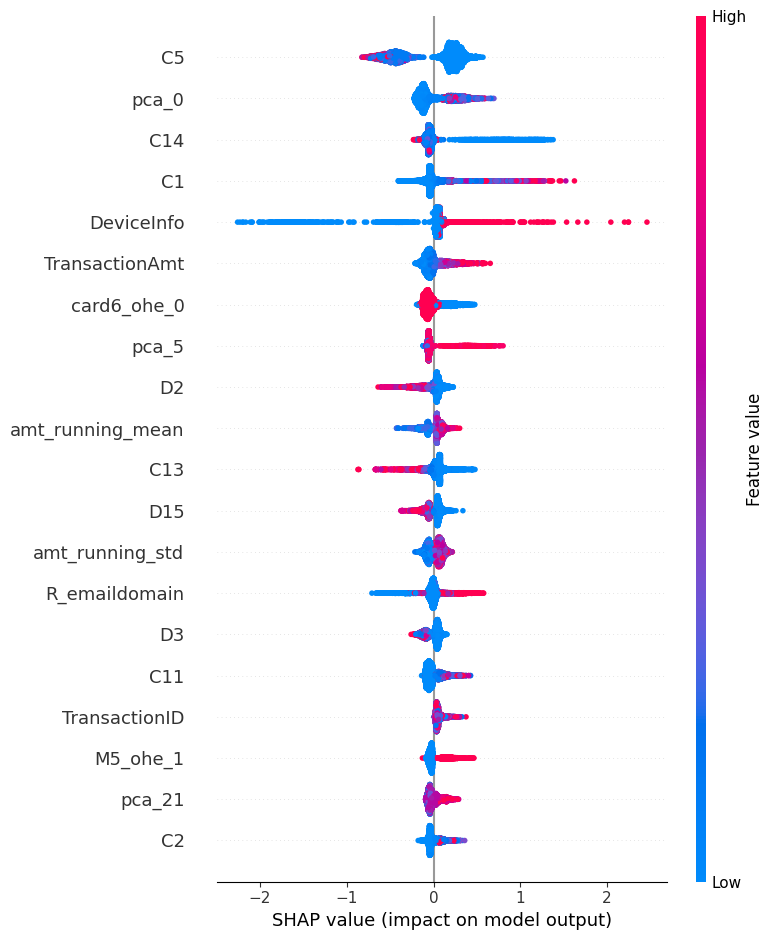

In [ ]:
import shap

# Build SHAP explainer using the tuned model
explainer = shap.TreeExplainer(tuned_lgbm)

# Compute SHAP values on a sample of test data
# We use 10000 rows — computing on all 104k would take too long
X_test_sample = X_test.iloc[:10000]
shap_values = explainer.shap_values(X_test_sample)

# Global feature importance — which features matter most overall
shap.summary_plot(shap_values, X_test_sample, max_display=20)

- DeviceInfo is the most spread out feature — it has dots stretching all the way to +2.5. Certain devices are extremely strong fraud signals. High DeviceInfo value (red dots) pushes strongly toward fraud.
- **C1 and C14**  these are anonymized count features. High values push toward fraud significantly.
- **TransactionAmt**  higher amounts (red) push toward fraud, lower amounts (blue) push away. Makes intuitive sense.
- **D2**  a time delta feature. Low values (blue) push toward fraud — meaning transactions happening shortly after account activity are more suspicious.
- **amt_running_mean**  the blue dots (low running mean) are mostly centered around 0 or slightly left, meaning they push slightly away from fraud or are neutral.
The red dots (high running mean) have more spread toward fraud territory.

LOCAL SHAP (why did the model flag this specific transaction)

first transaction of the test set

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


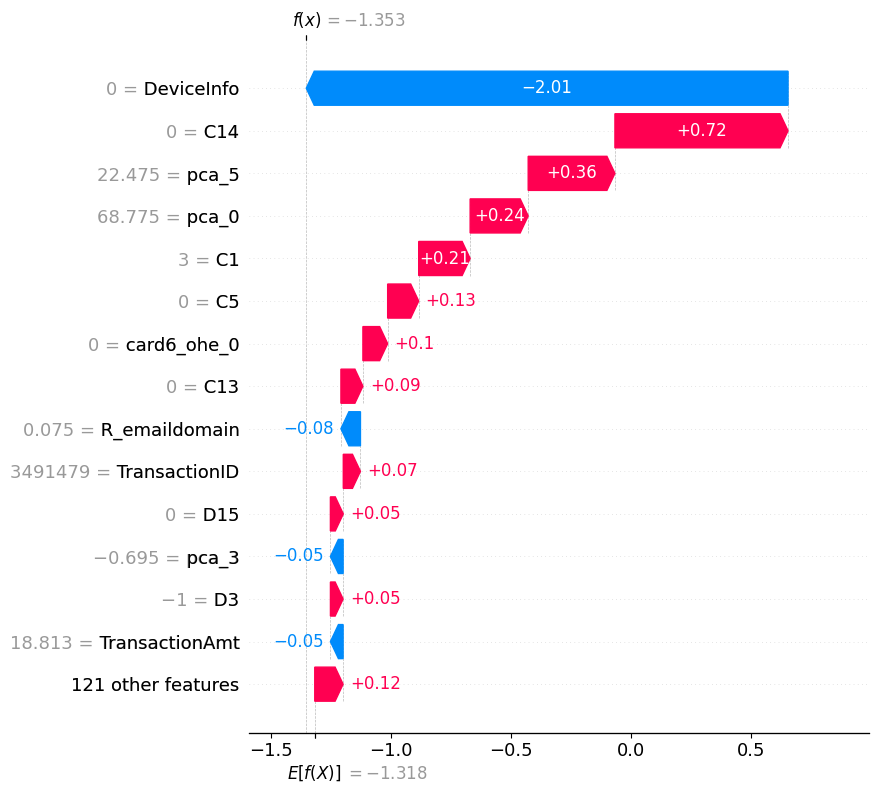

In [ ]:
# Pick a fraud transaction from test set
fraud_indices = y_test[y_test == 1].index
sample_idx = fraud_indices[0]
sample_position = X_test.index.get_loc(sample_idx)

# Get SHAP values for this one transaction
single_shap = explainer.shap_values(X_test.iloc[[sample_position]])

# Waterfall plot
shap.waterfall_plot(
    shap.Explanation(
        values=single_shap[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_position],
        feature_names=X_test.columns.tolist()
    ),
    max_display=15
)

- DeviceInfo = -2.01 — massive blue bar pushing strongly away from fraud. This device is associated with legitimate transactions in the training data. This single feature almost decided the outcome alone.
- C14 = +0.72, pca_5 = +0.36, pca_0 = +0.24 — these pushed toward fraud but couldn't overcome the DeviceInfo signal.
- R_emaildomain = -0.08 and TransactionAmt = -0.05 — also pushed slightly away from fraud.

  
This fraudster used a device that the model associates strongly with legitimate transactions — possibly a stolen device that has a clean history. The fraud signals were there (C14, PCA components) but the device fingerprint overrode them.

save the model

In [ ]:
joblib.dump(tuned_lgbm, "/content/drive/MyDrive/fraud_detection/lgbm_final.pkl")
print("Final model saved ✅")

Final model saved ✅


# 📊 Phase 4 — MLOps (MLflow + Drift Monitoring)

loading back

In [ ]:
import pandas as pd
import numpy as np
import joblib
from google.colab import drive

drive.mount('/content/drive')

train_pd = pd.read_parquet("/content/drive/MyDrive/fraud_detection/train_final.parquet")
test_pd = pd.read_parquet("/content/drive/MyDrive/fraud_detection/test_final.parquet")

TARGET = "isFraud"
X_train = train_pd.drop(columns=[TARGET])
y_train = train_pd[TARGET]
X_test = test_pd.drop(columns=[TARGET])
y_test = test_pd[TARGET]

tuned_lgbm = joblib.load("/content/drive/MyDrive/fraud_detection/lgbm_final.pkl")
scale = (len(y_train) - y_train.sum()) / y_train.sum()

print("Everything loaded ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Everything loaded ✅


In [ ]:
!pip install mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 892.1/892.1 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

MLFLOW

with our best model

In [ ]:
import mlflow
import mlflow.lightgbm
from sklearn.metrics import roc_auc_score, classification_report, f1_score, recall_score, precision_score

# Set experiment name
mlflow.set_experiment("fraud-detection")

# Define the parameters we used
best_params = {
    "n_estimators": 196,
    "max_depth": 8,
    "learning_rate": 0.016550473521207053,
    "num_leaves": 53,
    "min_child_samples": 78,
    "scale_pos_weight": round(scale, 2),
    "threshold": 0.35
}

with mlflow.start_run(run_name="lgbm_tuned_final"):

    # Log parameters
    mlflow.log_params(best_params)

    # Get predictions
    y_prob = tuned_lgbm.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.35).astype(int)

    # Log metrics
    mlflow.log_metric("auc_roc", roc_auc_score(y_test, y_prob))
    mlflow.log_metric("recall", recall_score(y_test, y_pred))
    mlflow.log_metric("precision", precision_score(y_test, y_pred))
    mlflow.log_metric("f1", f1_score(y_test, y_pred))

    # Log model
    mlflow.lightgbm.log_model(tuned_lgbm, "model")

    print("Run logged ✅")
    print("AUC-ROC:", round(roc_auc_score(y_test, y_prob), 4))
    print("Recall:", round(recall_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))

2026/05/21 00:05:51 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/21 00:05:51 INFO mlflow.store.db.utils: Updating database tables
2026/05/21 00:05:53 INFO mlflow.tracking.fluent: Experiment with name 'fraud-detection' does not exist. Creating a new experiment.
2026/05/21 00:05:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 00:05:56 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run logged ✅
AUC-ROC: 0.8897
Recall: 0.8453
Precision: 0.1085


with the other models

In [ ]:
xgb_model = joblib.load("/content/drive/MyDrive/fraud_detection/xgb_baseline.pkl")
lgbm_baseline = joblib.load("/content/drive/MyDrive/fraud_detection/lgbm_baseline.pkl")

# Log XGBoost baseline
with mlflow.start_run(run_name="xgb_baseline"):
    mlflow.log_params({"n_estimators": 300, "max_depth": 6,
                       "learning_rate": 0.05, "threshold": 0.5})

    y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
    y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)

    mlflow.log_metric("auc_roc", roc_auc_score(y_test, y_prob_xgb))
    mlflow.log_metric("recall", recall_score(y_test, y_pred_xgb))
    mlflow.log_metric("precision", precision_score(y_test, y_pred_xgb))
    mlflow.log_metric("f1", f1_score(y_test, y_pred_xgb))
    mlflow.lightgbm.log_model(xgb_model, "model")
    print("XGBoost baseline logged ✅")

# Log LightGBM baseline
with mlflow.start_run(run_name="lgbm_baseline"):
    mlflow.log_params({"n_estimators": 300, "max_depth": 6,
                       "learning_rate": 0.05, "threshold": 0.5})

    y_prob_lgbm = lgbm_baseline.predict_proba(X_test)[:, 1]
    y_pred_lgbm = (y_prob_lgbm >= 0.5).astype(int)

    mlflow.log_metric("auc_roc", roc_auc_score(y_test, y_prob_lgbm))
    mlflow.log_metric("recall", recall_score(y_test, y_pred_lgbm))
    mlflow.log_metric("precision", precision_score(y_test, y_pred_lgbm))
    mlflow.log_metric("f1", f1_score(y_test, y_pred_lgbm))
    mlflow.lightgbm.log_model(lgbm_baseline, "model")
    print("LightGBM baseline logged ✅")

2026/05/21 00:06:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 00:06:15 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost baseline logged ✅


2026/05/21 00:06:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 00:06:40 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LightGBM baseline logged ✅


compare paramertres

In [ ]:
# Save MLflow runs to Drive so they persist
import shutil

mlflow_path = "/content/drive/MyDrive/fraud_detection/mlruns"
shutil.copytree("mlruns", mlflow_path, dirs_exist_ok=True)

print("MLflow runs saved to Drive ✅")

# Compare all runs programmatically
runs = mlflow.search_runs(experiment_names=["fraud-detection"])
print(runs[["tags.mlflow.runName", "metrics.auc_roc",
            "metrics.recall", "metrics.precision", "metrics.f1"]])

MLflow runs saved to Drive ✅
  tags.mlflow.runName  metrics.auc_roc  metrics.recall  metrics.precision  \
0       lgbm_baseline         0.881914        0.754071           0.174552   
1        xgb_baseline         0.873263        0.730208           0.183946   
2    lgbm_tuned_final         0.889661        0.845312           0.108481   

   metrics.f1  
0    0.283483  
1    0.293865  
2    0.192286  


## Drift Monitoring (KS-test + Chi-square)

In [ ]:
from scipy import stats

reference = train_pd.sample(5000, random_state=42)
current = test_pd.sample(2000, random_state=42)

drift_results = []

for col in train_pd.columns:
    if col == "isFraud":
        continue

    ref_col = reference[col].dropna()
    cur_col = current[col].dropna()

    try:
        # Numerical columns — KS test
        if train_pd[col].dtype in ["float64", "float32", "int64", "int32"]:
            stat, p_value = stats.ks_2samp(ref_col, cur_col)
            test_used = "KS"
        # Categorical/binary columns — Chi-square test
        else:
            categories = set(ref_col.unique()) | set(cur_col.unique())
            ref_counts = ref_col.value_counts().reindex(categories, fill_value=0)
            cur_counts = cur_col.value_counts().reindex(categories, fill_value=0)
            stat, p_value = stats.chisquare(cur_counts, ref_counts / ref_counts.sum() * cur_counts.sum())
            test_used = "Chi-square"

        drift_results.append({
            "feature": col,
            "test": test_used,
            "p_value": round(p_value, 4),
            "drifted": p_value < 0.05
        })
    except:
        continue

drift_df = pd.DataFrame(drift_results).sort_values("p_value")

print(f"Total features checked: {len(drift_df)}")
print(f"Features with drift: {drift_df['drifted'].sum()}")
print("\nTop 15 most drifted features:")
print(drift_df.head(15))

Total features checked: 135
Features with drift: 80

Top 15 most drifted features:
             feature test  p_value  drifted
1              id_31   KS      0.0     True
4      TransactionID   KS      0.0     True
5      TransactionDT   KS      0.0     True
28                D1   KS      0.0     True
31                D4   KS      0.0     True
30                D3   KS      0.0     True
29                D2   KS      0.0     True
22                C9   KS      0.0     True
62          M1_ohe_0   KS      0.0     True
47   amt_running_std   KS      0.0     True
46  amt_running_mean   KS      0.0     True
37             id_02   KS      0.0     True
35               D15   KS      0.0     True
34               D11   KS      0.0     True
33               D10   KS      0.0     True


In [ ]:
print("Features with NO drift:")
print(drift_df[drift_df["drifted"] == False][["feature", "p_value"]])

Features with NO drift:
                  feature  p_value
15                     C2   0.0536
39                  id_06   0.0765
48             amt_zscore   0.0765
13                  dist1   0.0826
14                     C1   0.0892
65               M2_ohe_1   0.0908
133  amount_to_mean_ratio   0.0926
96            id_37_ohe_0   0.1016
10                  card5   0.1035
36                  id_01   0.1637
2           R_emaildomain   0.1665
101      DeviceType_ohe_1   0.2726
71               M5_ohe_0   0.2893
100      DeviceType_ohe_0   0.2935
19                     C6   0.3022
27                    C14   0.3111
51        ProductCD_ohe_2   0.3294
18                     C5   0.3388
11                  addr1   0.4313
99            id_38_ohe_1   0.5241
97            id_37_ohe_1   0.6049
68               M4_ohe_0   0.7255
8                   card2   0.7564
59            card6_ohe_1   0.7805
7                   card1   0.8153
24                    C11   0.8920
54            card4_ohe_0   0.8

In [ ]:

# Get SHAP importance from Phase 3
explainer = shap.TreeExplainer(tuned_lgbm)
X_test_sample = X_test.iloc[:2000]
shap_values = explainer.shap_values(X_test_sample)

# Compute mean absolute SHAP value per feature
shap_importance = pd.DataFrame({
    "feature": X_test.columns,
    "shap_importance": np.abs(shap_values).mean(axis=0)
}).sort_values("shap_importance", ascending=False)

# Merge with drift results
combined = shap_importance.merge(drift_df[["feature", "p_value", "drifted"]],
                                  on="feature", how="left")

# Flag features that are both important AND drifting
combined["high_risk"] = (combined["shap_importance"] > combined["shap_importance"].quantile(0.75)) & \
                         (combined["drifted"] == True)

print("High risk features — important AND drifting:")
print(combined[combined["high_risk"] == True][["feature", "shap_importance", "p_value"]].head(15))

High risk features — important AND drifting:
             feature  shap_importance  p_value
1              pca_0         0.163805   0.0000
3     TransactionAmt         0.103561   0.0189
5                 D2         0.089417   0.0000
6   amt_running_mean         0.083878   0.0000
7                D15         0.082100   0.0000
8                C13         0.079579   0.0031
10             pca_5         0.077969   0.0000
11                D3         0.072641   0.0000
12        DeviceInfo         0.068286   0.0202
13     TransactionID         0.066914   0.0000
15   amt_running_std         0.063103   0.0000
18            pca_21         0.056374   0.0020
20                D4         0.052215   0.0000
23                D5         0.040453   0.0000
25             pca_3         0.036012   0.0000


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


saving the report

In [ ]:
combined.to_csv("/content/drive/MyDrive/fraud_detection/drift_shap_report.csv", index=False)
print("Report saved ✅")

Report saved ✅
